# Quick start

This notebook walks through the core xhycom workflow: opening HYCOM `.ab` files
directly into labelled `xr.Dataset` objects, slicing, and plotting.

In [1]:
import xhycom

Set the paths below to point at your data before running.

In [2]:
GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"  # directory containing archv.*.ab or archm.*.ab

## Open the grid and bathymetry

In [3]:
ds_grid = xhycom.open_dataset(GRID_PATH)

In [4]:
ds_grid

<xarray.Dataset> Size: 23MB
Dimensions:  (y: 380, x: 400)
Dimensions without coordinates: y, x
Data variables: (12/19)
    plon     (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    plat     (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    qlon     (y, x) float64 1MB -94.76 -94.6 -94.43 -94.27 ... 99.07 98.94 98.8
    qlat     (y, x) float64 1MB 38.94 39.04 39.14 39.24 ... 56.47 56.38 56.29
    ulon     (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    ulat     (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    ...       ...
    scux     (y, x) float64 1MB 1.811e+04 1.813e+04 ... 1.327e+04 1.327e+04
    scuy     (y, x) float64 1MB 1.811e+04 1.813e+04 ... 1.327e+04 1.327e+04
    scvx     (y, x) float64 1MB 1.812e+04 1.814e+04 ... 1.328e+04 1.327e+04
    scvy     (y, x) float64 1MB 1.812e+04 1.814e+04 ... 1.328e+04 1.327e+04
    cori     (y, x) float64 1MB 9.167e-05 9.187e-05 ... 0.0001214 0.0001213
    pasp     (y, x) float64 1MB 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [5]:
# Bathymetry: grid= is required to supply dimensions and coordinates
ds_bathy = xhycom.open_dataset(BATHY_PATH, grid=GRID_PATH)

In [6]:
ds_bathy

<xarray.Dataset> Size: 4MB
Dimensions:  (y: 380, x: 400)
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
Dimensions without coordinates: y, x
Data variables:
    depth    (y, x) float64 1MB nan nan nan nan nan nan ... nan nan nan nan nan

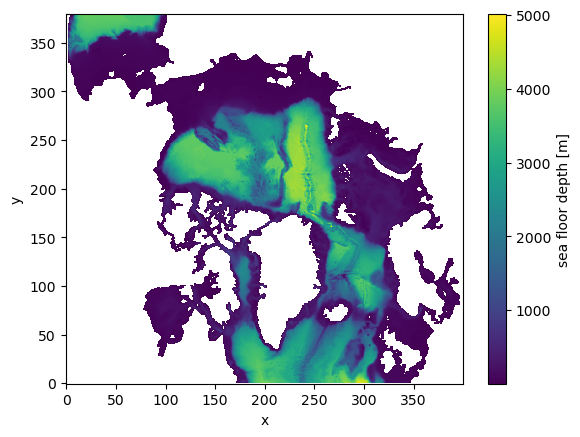

In [7]:
ds_bathy.depth.plot()

In [8]:
land_mask = ds_bathy.depth.isnull()
mask = 1 - land_mask

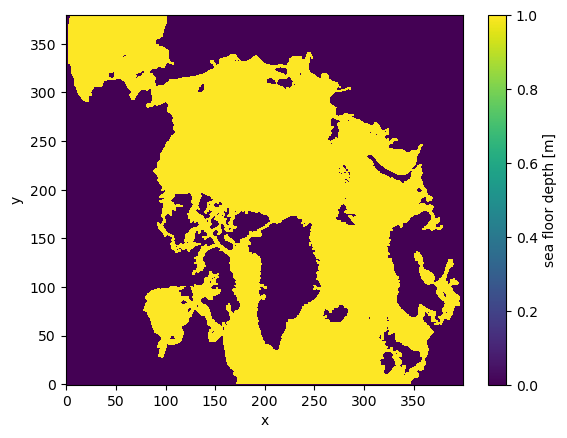

In [9]:
mask.plot()

## Open a single archive snapshot

`open_dataset` auto-detects the file type (archive, grid, bathymetry) from the
`.b` header.  When `grid=` is provided, appropriate `lon`/`lat` coordinates are
attached to each variable based on its staggering point on the Arakawa C-grid.

In [10]:
ds = xhycom.open_dataset(DATA_PATH + "archm.2020_001_12", grid=GRID_PATH)

In [11]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 1, y: 380, x: 400, k: 50, ki: 51)
Coordinates:
  * time        (time) object 8B 2020-01-01 00:00:00
    lon         (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat         (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u       (y, x) float64 1MB -94.83 -94.67 -94.5 ... 99.16 99.02 98.89
    lat_u       (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v       (y, x) float64 1MB -94.68 -94.52 -94.35 ... 99.0 98.87 98.74
    lat_v       (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B 0.1 0.2 0.3 0.4 0.5 ... 28.09 28.1 28.11 28.12
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    srfhgt      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    oneta       (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    surflx      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    wtrflx      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    salflx      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    ...          ...
    CO2_wind    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    ECO_bots    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    surface__1  (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    surface__2  (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    si_u        (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    si_v        (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

Every variable carries CF-style metadata (`long_name`, `units`) read from xhycom's
built-in lookup table:

```python
ds["temp"].attrs   # → {'long_name': 'sea water potential temperature', 'units': 'degC'}
```

Dimension and coordinate attrs are also set:
- `k` / `ki`, layer centres / interfaces, `axis: Z`
- `lon` / `lat`, T-point; `lon_u` / `lat_u`, U-point; `lon_v` / `lat_v`, V-point
- `dens`, target sigma-2 density for each layer

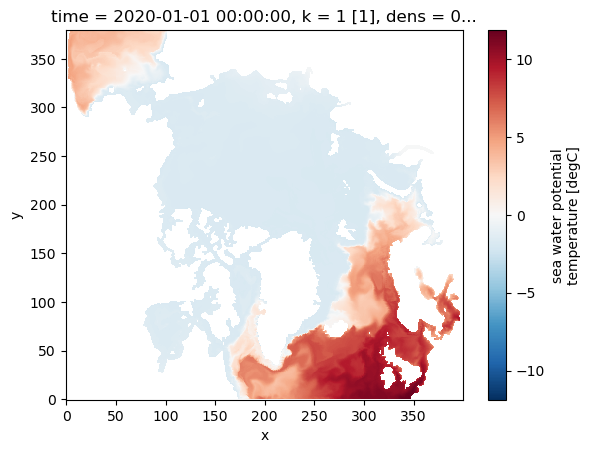

In [12]:
ds.temp.isel(time=0, k=0).plot()

## What's next

- **[Lazy loading & chunking](lazy-loading.ipynb)**: open multi-year archives without loading data into memory, choose chunk sizes, and filter to only the variables you need.
- **[Working with HYCOM data](analysis.ipynb)**: slicing, plotting, time operations, `groupby`, and seasonal analysis once the Dataset is open.